Using device: mps
Using 5 filtered members from softmax_ensemble_analysis_results.json
Loaded symmetric calibration scale: 0.700
Loading cached PPE mean from ppe_train_mean.nc
Preparing sample 259...
Running ensemble inference...


100%|██████████| 5/5 [00:02<00:00,  1.80it/s]


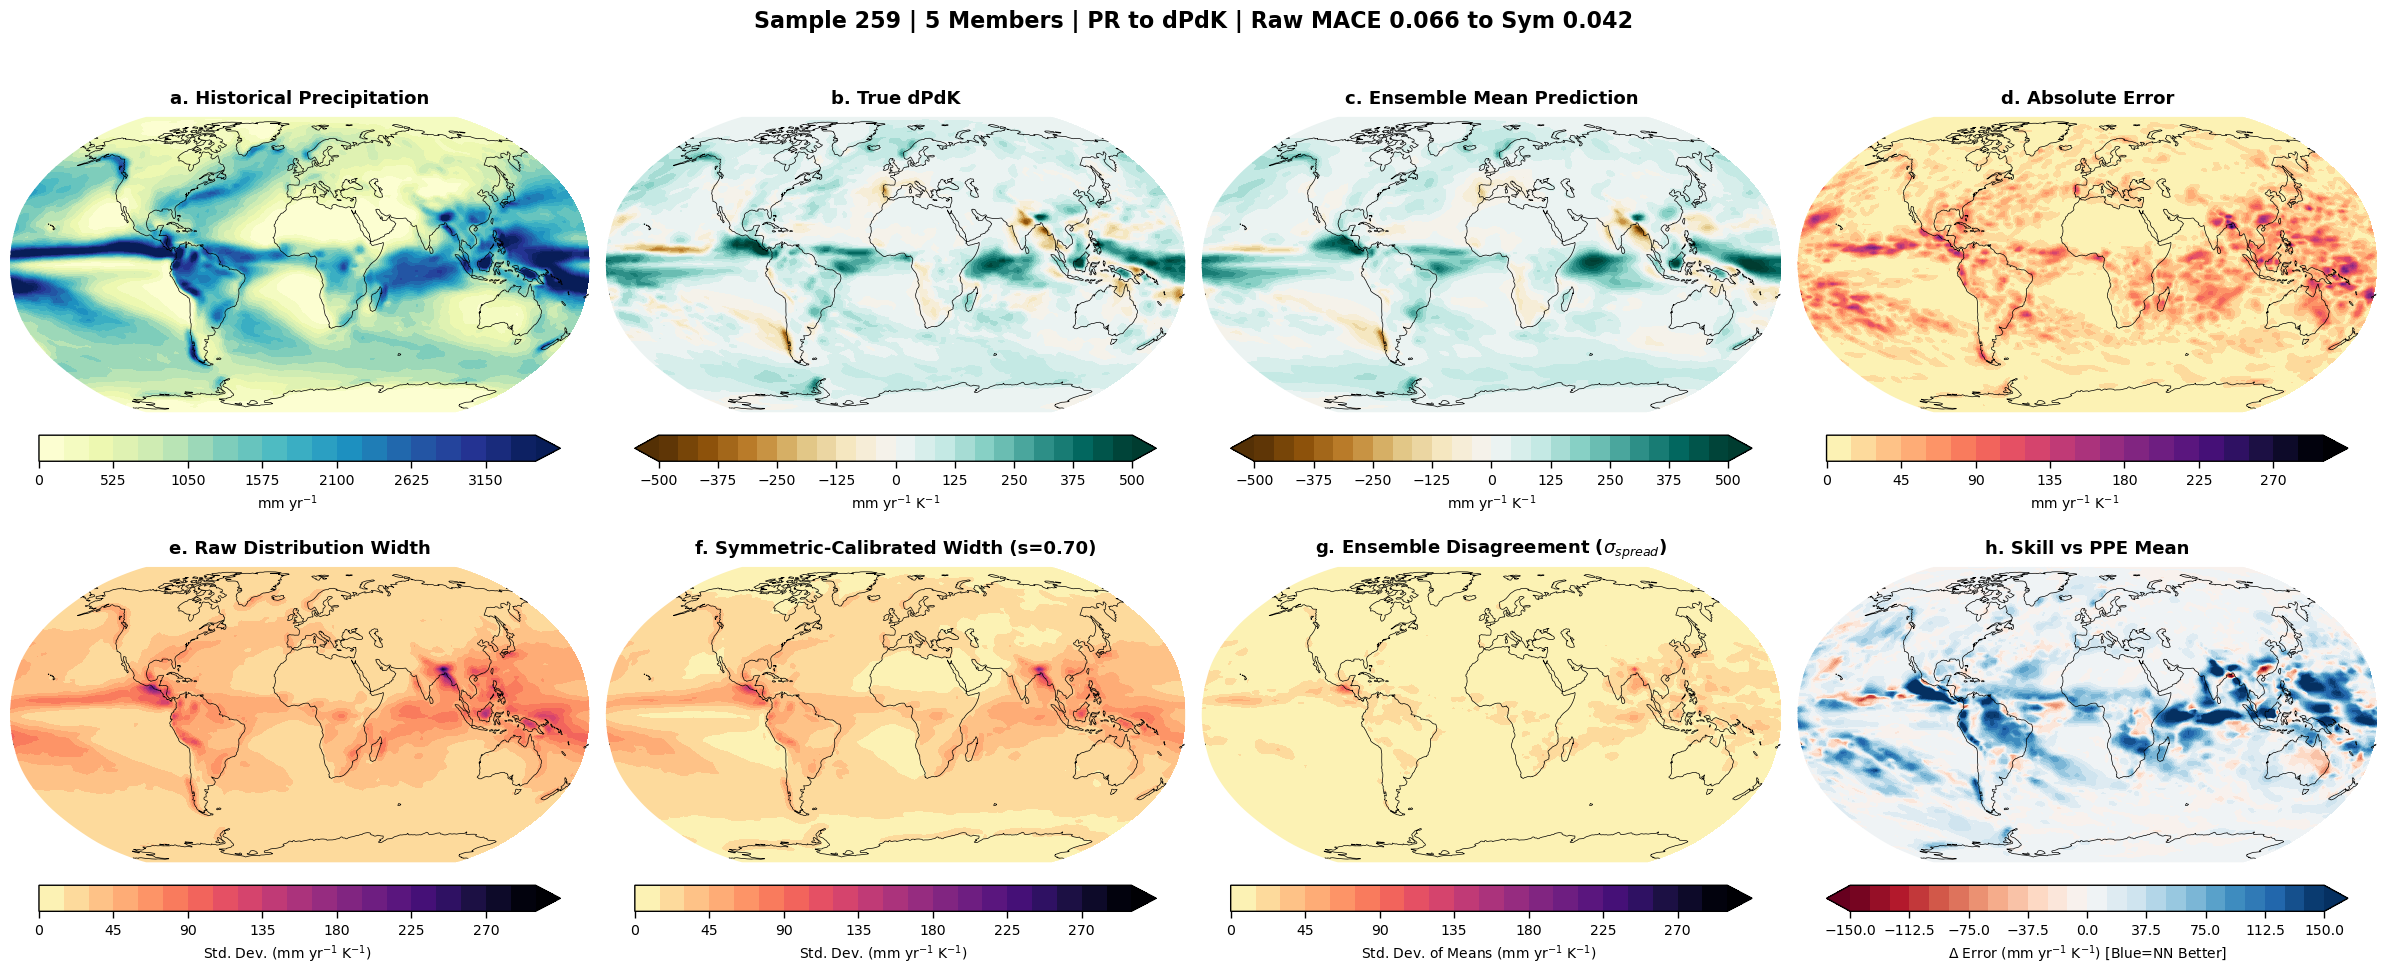


MAP SUMMARY
Members used:                      5

Global:
  Pixels:                           24576
  Mean NN error:                    17.39 mm/yr/K
  Mean PPE error:                   29.83 mm/yr/K
  Relative error reduction:         41.7%
  Mean skill (PPE error - NN error): 12.44 mm/yr/K
  Median skill:                     2.97 mm/yr/K
  NN better than PPE:               68.3% of pixels
  Mean raw sigma_total:             31.46 mm/yr/K
  Mean calibrated sigma_total:      22.02 mm/yr/K
  Mean sigma_spread:                6.28 mm/yr/K

Land Only:
  Pixels:                           9296
  Mean NN error:                    13.19 mm/yr/K
  Mean PPE error:                   22.72 mm/yr/K
  Relative error reduction:         42.0%
  Mean skill (PPE error - NN error): 9.53 mm/yr/K
  Median skill:                     2.24 mm/yr/K
  NN better than PPE:               72.2% of pixels
  Mean raw sigma_total:             28.32 mm/yr/K
  Mean calibrated sigma_total:      19.82 mm/yr/K
  Mean sig

In [1]:
import json
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"shapely(\\..*)?",
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"cartopy(\\..*)?",
)

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import xarray as xr
from tqdm import tqdm

from unet import ProbUNet



# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
sample_idx = 259  # absolute realization index in GA789 files

lat_dim = 128
num_bins = 64
base_channels = 200
gn_groups = 1
kernel_size = 3
dP_min = -700
dP_max = 1200

prefer_good_members = True
use_symmetric_calibration = True


# ==============================================================================
# 2. PATHS
# ==============================================================================
base_dir = Path("/Users/ewellmeyer/Documents/research")
data_dir = base_dir / "HadGEM"
weights_dir = base_dir / "weights"

input_file = data_dir / f"GA789_PR_his_rg{lat_dim}.nc"
truth_file = data_dir / f"GA789_dPdK_rg{lat_dim}.nc"
landmask_file = data_dir / "hadgem_landmask_rg128.nc"

ens_name = (
    f"unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch{base_channels}_k{kernel_size}_"
    f"{lat_dim}x_dPbins{num_bins}_gn{gn_groups}_dpmin{dP_min}_dPmax{dP_max}_sigma0.6"
)
ens_dir = weights_dir / ens_name

norm_stats_path = ens_dir / "norm_stats.json"
bin_info_path = ens_dir / "born_bins.json"
splits_path = ens_dir / "data_splits.npz"
analysis_path = ens_dir / "softmax_ensemble_analysis_results.json"
calibration_path = ens_dir / "temperature_calibration.json"

ppe_mean_cache = ens_dir / "ppe_train_mean.nc"
figure_path = ens_dir / f"ensemble_maps_sample_{sample_idx}_symcal.png"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


# ==============================================================================
# 3. HELPERS
# ==============================================================================
def get_member_files():
    member_files = sorted(ens_dir.glob(f"{ens_dir.name}_member*.pth"))
    if not member_files:
        raise RuntimeError(f"No ensemble members found in {ens_dir}")

    if prefer_good_members and analysis_path.exists():
        with open(analysis_path, "r") as f:
            analysis = json.load(f)
        good_members = analysis.get("good_members", [])
        if good_members:
            member_files = [member_files[i] for i in good_members]
            print(f"Using {len(member_files)} filtered members from {analysis_path.name}")
            return member_files

    print(f"Using all {len(member_files)} members")
    return member_files


def get_symmetric_scale():
    if not use_symmetric_calibration:
        print("Symmetric calibration disabled")
        return 1.0, None

    if not calibration_path.exists():
        print("No calibration summary found; using raw uncertainty")
        return 1.0, None

    with open(calibration_path, "r") as f:
        cal = json.load(f)

    sym = cal.get("validation_symmetric_best", {})
    scale = float(sym.get("scale", 1.0))
    print(f"Loaded symmetric calibration scale: {scale:.3f}")
    return scale, cal


def get_ppe_train_mean(train_indices):
    if ppe_mean_cache.exists():
        print(f"Loading cached PPE mean from {ppe_mean_cache.name}")
        with xr.open_dataset(ppe_mean_cache) as ds_mean:
            return ds_mean["dPdK_mean"].values

    print(f"Computing PPE training mean from {len(train_indices)} samples...")
    with xr.open_dataset(truth_file) as ds_truth:
        ppe_mean = ds_truth["dPdK"].isel(realization=train_indices).mean(dim="realization").values
        ds_mean = xr.Dataset(
            {"dPdK_mean": (["latitude", "longitude"], ppe_mean)},
            coords={"latitude": ds_truth.latitude, "longitude": ds_truth.longitude},
        )
        ds_mean.to_netcdf(ppe_mean_cache)

    return ppe_mean


def get_ensemble_metrics(realization_idx, member_files, sym_scale):
    print(f"Preparing sample {realization_idx}...")

    with open(norm_stats_path, "r") as f:
        ns = json.load(f)
    x_mean = np.array(ns["x_mean"], dtype=np.float32).reshape(1, 1, 1, 1)
    x_std = np.array(ns["x_std"], dtype=np.float32).reshape(1, 1, 1, 1)
    y_mean = float(ns["y_mean"])
    y_std = float(ns["y_std"])

    with open(bin_info_path, "r") as f:
        bi = json.load(f)
    bin_centers = np.array(bi["bin_centers_norm"], dtype=np.float32)
    bin_centers_t = torch.tensor(bin_centers, dtype=torch.float32, device=device).view(1, -1, 1, 1)

    with xr.open_dataset(input_file) as ds_in, xr.open_dataset(truth_file) as ds_truth:
        ds_in_one = ds_in.isel(realization=realization_idx)
        ds_truth_one = ds_truth.isel(realization=realization_idx)
        lats = ds_in_one.latitude.values
        lons = ds_in_one.longitude.values
        x_pr = ds_in_one["PR"].values[np.newaxis, np.newaxis, ...]
        y_true = ds_truth_one["dPdK"].values

    x_norm = (x_pr - x_mean) / x_std
    x_in = torch.tensor(x_norm, dtype=torch.float32, device=device)

    model = ProbUNet(1, base_channels, kernel_size, 0.0, num_bins, gn_groups=gn_groups).to(device)
    accum_probs = torch.zeros((1, num_bins, len(lats), len(lons)), dtype=torch.float32, device=device)
    accum_mu = torch.zeros((1, 1, len(lats), len(lons)), dtype=torch.float32, device=device)
    accum_mu_sq = torch.zeros((1, 1, len(lats), len(lons)), dtype=torch.float32, device=device)

    print("Running ensemble inference...")
    with torch.inference_mode():
        for member_file in tqdm(member_files):
            ckpt = torch.load(member_file, map_location=device)
            state = ckpt["model"] if "model" in ckpt else ckpt
            model.load_state_dict(state, strict=False)
            model.eval()

            probs = model.forward_components(x_in).float()
            accum_probs += probs

            mu_mem_norm = (probs * bin_centers_t).sum(dim=1, keepdim=True)
            accum_mu += mu_mem_norm
            accum_mu_sq += mu_mem_norm ** 2

    n_members = len(member_files)
    avg_probs = accum_probs / n_members

    mu_total_norm = (avg_probs * bin_centers_t).sum(dim=1)
    var_total_raw_norm = (avg_probs * (bin_centers_t - mu_total_norm.unsqueeze(1)) ** 2).sum(dim=1)
    sigma_total_raw_norm = torch.sqrt(torch.clamp(var_total_raw_norm, min=0.0))
    sigma_total_cal_norm = sigma_total_raw_norm * np.float32(sym_scale)

    mean_of_means = accum_mu / n_members
    mean_of_sqs = accum_mu_sq / n_members
    var_spread_norm = torch.clamp(mean_of_sqs - (mean_of_means ** 2), min=0.0)
    sigma_spread_norm = torch.sqrt(var_spread_norm).squeeze(1)

    pred_mm = mu_total_norm.cpu().numpy().squeeze() * y_std + y_mean
    sigma_total_raw_mm = sigma_total_raw_norm.cpu().numpy().squeeze() * y_std
    sigma_total_cal_mm = sigma_total_cal_norm.cpu().numpy().squeeze() * y_std
    sigma_spread_mm = sigma_spread_norm.cpu().numpy().squeeze() * y_std

    return {
        "lats": lats,
        "lons": lons,
        "x_pr": x_pr.squeeze(),
        "y_true": y_true.squeeze(),
        "pred": pred_mm,
        "sigma_total_raw": sigma_total_raw_mm,
        "sigma_total_cal": sigma_total_cal_mm,
        "sigma_spread": sigma_spread_mm,
    }


def format_ax(ax, title):
    ax.coastlines(linewidth=0.5, color="black")
    ax.set_title(title, fontsize=13, pad=10, fontweight="bold")
    ax.axis("off")


# ==============================================================================
# 4. RUN
# ==============================================================================
if not splits_path.exists():
    raise FileNotFoundError(f"Split file not found: {splits_path}")
if sample_idx < 0:
    raise ValueError("sample_idx must be non-negative")

splits = np.load(splits_path)
train_indices = splits["train"].tolist()

member_files = get_member_files()
sym_scale, cal_summary = get_symmetric_scale()
ppe_train_mean = get_ppe_train_mean(train_indices)
with xr.open_dataset(landmask_file) as ds_land:
    landmask = ds_land["land_mask"].values.astype(bool)

results = get_ensemble_metrics(sample_idx, member_files, sym_scale)
lats = results["lats"]
lons = results["lons"]
p_hist = results["x_pr"]
dP_target = results["y_true"]
dP_pred = results["pred"]
sigma_total_raw = results["sigma_total_raw"]
sigma_total_cal = results["sigma_total_cal"]
sigma_spread = results["sigma_spread"]

nn_error = np.abs(dP_pred - dP_target)
ppe_error = np.abs(ppe_train_mean - dP_target)
skill_map = ppe_error - nn_error

sns.set_context("paper", font_scale=1.15)
fig = plt.figure(figsize=(24, 10))

proj = ccrs.Robinson(central_longitude=0)
trans = ccrs.PlateCarree()

ax1 = plt.subplot(2, 4, 1, projection=proj)
im1 = ax1.contourf(lons, lats, p_hist, transform=trans, levels=np.linspace(0, 3500, 21), cmap="YlGnBu", extend="max")
format_ax(ax1, "a. Historical Precipitation")
cb1 = plt.colorbar(im1, ax=ax1, orientation="horizontal", pad=0.05, shrink=0.9)
cb1.set_label(r"mm yr$^{-1}$", fontsize=10)

ax2 = plt.subplot(2, 4, 2, projection=proj)
im2 = ax2.contourf(lons, lats, dP_target, transform=trans, levels=np.linspace(-500, 500, 25), cmap="BrBG", extend="both")
format_ax(ax2, "b. True dPdK")
cb2 = plt.colorbar(im2, ax=ax2, orientation="horizontal", pad=0.05, shrink=0.9)
cb2.set_label(r"mm yr$^{-1}$ K$^{-1}$", fontsize=10)

ax3 = plt.subplot(2, 4, 3, projection=proj)
im3 = ax3.contourf(lons, lats, dP_pred, transform=trans, levels=np.linspace(-500, 500, 25), cmap="BrBG", extend="both")
format_ax(ax3, "c. Ensemble Mean Prediction")
cb3 = plt.colorbar(im3, ax=ax3, orientation="horizontal", pad=0.05, shrink=0.9)
cb3.set_label(r"mm yr$^{-1}$ K$^{-1}$", fontsize=10)

ax4 = plt.subplot(2, 4, 4, projection=proj)
im4 = ax4.contourf(lons, lats, nn_error, transform=trans, levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(ax4, "d. Absolute Error")
cb4 = plt.colorbar(im4, ax=ax4, orientation="horizontal", pad=0.05, shrink=0.9)
cb4.set_label(r"mm yr$^{-1}$ K$^{-1}$", fontsize=10)

ax5 = plt.subplot(2, 4, 5, projection=proj)
im5 = ax5.contourf(lons, lats, sigma_total_raw, transform=trans, levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(ax5, "e. Raw Distribution Width")
cb5 = plt.colorbar(im5, ax=ax5, orientation="horizontal", pad=0.05, shrink=0.9)
cb5.set_label(r"Std. Dev. (mm yr$^{-1}$ K$^{-1}$)", fontsize=10)

ax6 = plt.subplot(2, 4, 6, projection=proj)
im6 = ax6.contourf(lons, lats, sigma_total_cal, transform=trans, levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(ax6, f"f. Symmetric-Calibrated Width (s={sym_scale:.2f})")
cb6 = plt.colorbar(im6, ax=ax6, orientation="horizontal", pad=0.05, shrink=0.9)
cb6.set_label(r"Std. Dev. (mm yr$^{-1}$ K$^{-1}$)", fontsize=10)

ax7 = plt.subplot(2, 4, 7, projection=proj)
im7 = ax7.contourf(lons, lats, sigma_spread, transform=trans, levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(ax7, r"g. Ensemble Disagreement ($\sigma_{spread}$)")
cb7 = plt.colorbar(im7, ax=ax7, orientation="horizontal", pad=0.05, shrink=0.9)
cb7.set_label(r"Std. Dev. of Means (mm yr$^{-1}$ K$^{-1}$)", fontsize=10)

ax8 = plt.subplot(2, 4, 8, projection=proj)
skill_levels = np.linspace(-150, 150, 25)
im8 = ax8.contourf(lons, lats, skill_map, transform=trans, levels=skill_levels, cmap="RdBu", extend="both")
format_ax(ax8, "h. Skill vs PPE Mean")
cb8 = plt.colorbar(im8, ax=ax8, orientation="horizontal", pad=0.05, shrink=0.9)
cb8.set_label(r"$\Delta$ Error (mm yr$^{-1}$ K$^{-1}$) [Blue=NN Better]", fontsize=10)

title = f"Sample {sample_idx} | {len(member_files)} Members | PR to dPdK"
if cal_summary is not None:
    raw_mace = cal_summary.get("test_raw", {}).get("mace")
    sym_mace = cal_summary.get("test_symmetric", {}).get("mace")
    if raw_mace is not None and sym_mace is not None:
        title += f" | Raw MACE {raw_mace:.3f} to Sym {sym_mace:.3f}"
plt.suptitle(title, fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout()
# plt.savefig(figure_path, dpi=300, bbox_inches="tight")
# print(f"\nFigure saved to: {figure_path}")
plt.show()

def print_region_summary(label, mask):
    region_nn_error = nn_error[mask]
    region_ppe_error = ppe_error[mask]
    region_skill = skill_map[mask]
    region_sigma_raw = sigma_total_raw[mask]
    region_sigma_cal = sigma_total_cal[mask]
    region_sigma_spread = sigma_spread[mask]
    pct_better = float(np.mean(region_skill > 0) * 100.0)
    print(f"\n{label}:")
    print(f"  Pixels:                           {int(mask.sum())}")
    print(f"  Mean NN error:                    {np.mean(region_nn_error):.2f} mm/yr/K")
    print(f"  Mean PPE error:                   {np.mean(region_ppe_error):.2f} mm/yr/K")
    print(f"  Relative error reduction:         {(1 - np.mean(region_nn_error) / np.mean(region_ppe_error)) * 100:.1f}%")
    print(f"  Mean skill (PPE error - NN error): {np.mean(region_skill):.2f} mm/yr/K")
    print(f"  Median skill:                     {np.median(region_skill):.2f} mm/yr/K")
    print(f"  NN better than PPE:               {pct_better:.1f}% of pixels")
    print(f"  Mean raw sigma_total:             {np.mean(region_sigma_raw):.2f} mm/yr/K")
    print(f"  Mean calibrated sigma_total:      {np.mean(region_sigma_cal):.2f} mm/yr/K")
    print(f"  Mean sigma_spread:                {np.mean(region_sigma_spread):.2f} mm/yr/K")

print("\n" + "=" * 60)
print("MAP SUMMARY")
print("=" * 60)
print(f"Members used:                      {len(member_files)}")
print_region_summary("Global", np.ones_like(landmask, dtype=bool))
print_region_summary("Land Only", landmask)
if cal_summary is not None:
    print("\nCalibration Diagnostics:")
    print(f"  Symmetric calibration scale:      {sym_scale:.3f}")
    print(f"  Validation symmetric MACE:        {cal_summary['validation_symmetric_best']['mace']:.4f}")
    print(f"  Test raw MACE:                    {cal_summary['test_raw']['mace']:.4f}")
    print(f"  Test symmetric MACE:              {cal_summary['test_symmetric']['mace']:.4f}")
print("=" * 60)


Test set: 304 samples
Running ensemble inference on test set...


Members: 100%|██████████| 5/5 [00:22<00:00,  4.52s/it]


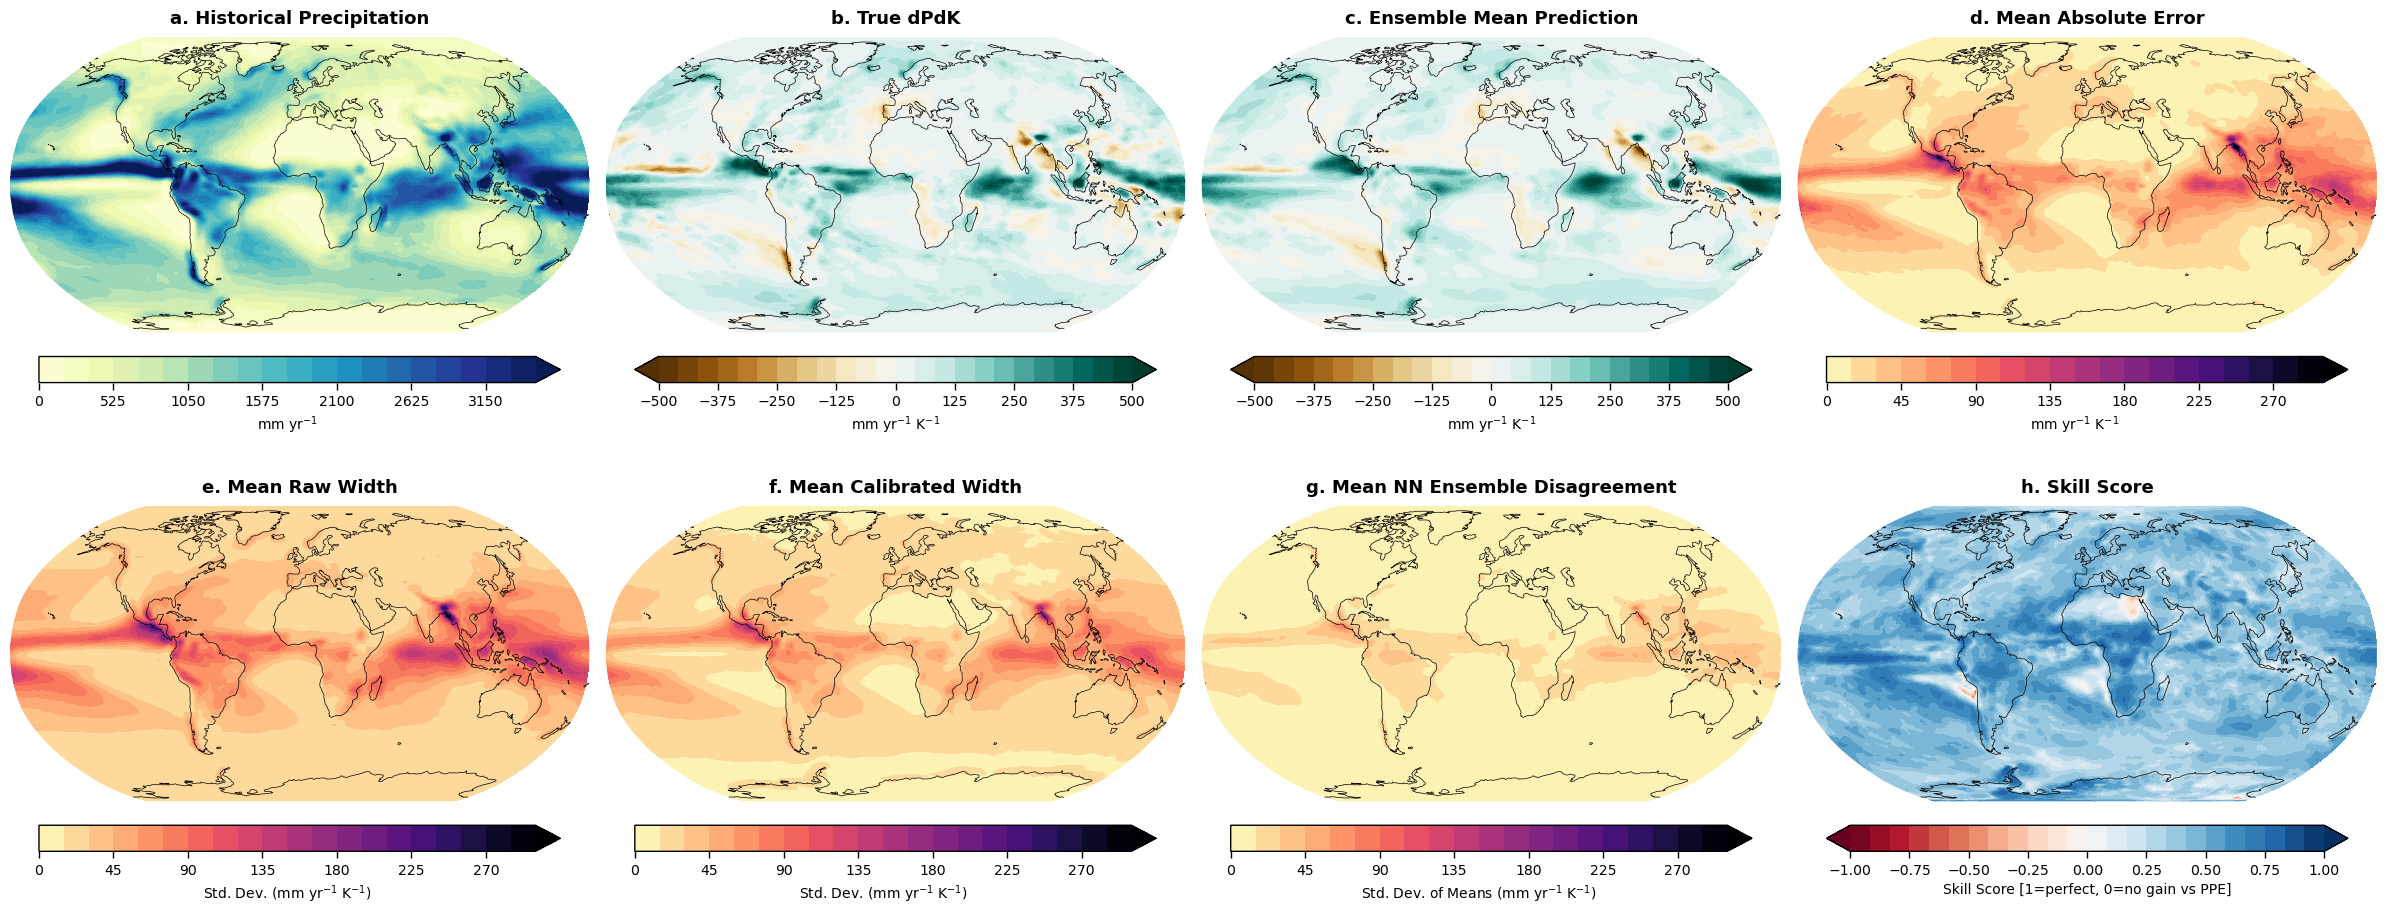

In [2]:

# ==============================================================================
# NEW FIGURE: test-set averaged maps (2×4, same layout/style as above)
# Panels a–c: same single sample (reuses data from cell above)
# Panels d–h: pixel-wise statistics over the full test set
#
# skill_method options for panel h:
#   "absolute"    — mean(|PPE_error| − |NN_error|) per pixel  [mm/yr/K, same as panel h above]
#   "skill_score" — 1 − MSE_NN/MSE_PPE per pixel             [dimensionless; 1=perfect, 0=no gain]
#   "pct_better"  — % of test samples where NN beats PPE      [0–100%]
# ==============================================================================

skill_method  = "skill_score"
batch_size_ts = 10   # inference batch size over test samples

# ── load test set ──────────────────────────────────────────────────────────────
test_indices = splits["test"].tolist()
N_test = len(test_indices)
print(f"Test set: {N_test} samples")

with xr.open_dataset(input_file) as _ds_in, xr.open_dataset(truth_file) as _ds_tgt:
    lats_ts = _ds_in.latitude.values
    lons_ts = _ds_in.longitude.values
    X_test  = _ds_in["PR"].values[test_indices].astype(np.float32)[:, np.newaxis]  # (N, 1, H, W)
    y_test  = _ds_tgt["dPdK"].values[test_indices].astype(np.float32)              # (N, H, W)

with open(norm_stats_path) as _f:
    _ns = json.load(_f)
_xm = np.array(_ns["x_mean"], dtype=np.float32).reshape(1, 1, 1, 1)
_xs = np.array(_ns["x_std"],  dtype=np.float32).reshape(1, 1, 1, 1)
_ym, _ys = float(_ns["y_mean"]), float(_ns["y_std"])

X_test_n = (X_test - _xm) / _xs

with open(bin_info_path) as _f:
    _bi = json.load(_f)
_bc_t    = torch.tensor(np.array(_bi["bin_centers_norm"], dtype=np.float32),
                         dtype=torch.float32, device=device).view(1, -1, 1, 1)
_bc_t_sq = _bc_t ** 2

H_ts, W_ts = lats_ts.shape[0], lons_ts.shape[0]

# Accumulators across ensemble members (memory-efficient; no per-bin storage needed).
# Uses the identity: total_var = mean_aleatoric_var + spread_var
#   where var_m = E[X²]_m − mu_m²  (per-member aleatoric variance)
acc_mu_sum  = np.zeros((N_test, H_ts, W_ts), dtype=np.float32)
acc_mu_sq   = np.zeros((N_test, H_ts, W_ts), dtype=np.float32)
acc_var_ale = np.zeros((N_test, H_ts, W_ts), dtype=np.float32)

_model_ts = ProbUNet(1, base_channels, kernel_size, 0.0, num_bins, gn_groups=gn_groups).to(device)

print("Running ensemble inference on test set...")
for _path in tqdm(member_files, desc="Members"):
    _ckpt  = torch.load(_path, map_location=device)
    _state = _ckpt["model"] if "model" in _ckpt else _ckpt
    _model_ts.load_state_dict(_state, strict=False)
    _model_ts.eval()
    with torch.inference_mode():
        for _i in range(0, N_test, batch_size_ts):
            _j   = min(_i + batch_size_ts, N_test)
            _xb  = torch.tensor(X_test_n[_i:_j], dtype=torch.float32, device=device)
            _prb = _model_ts.forward_components(_xb).float()          # (B, bins, H, W)
            _mu  = (_prb * _bc_t).sum(dim=1)                          # (B, H, W)
            _ex2 = (_prb * _bc_t_sq).sum(dim=1)
            _var = (_ex2 - _mu ** 2).clamp(min=0.0)
            acc_mu_sum [_i:_j] += _mu.cpu().numpy()
            acc_mu_sq  [_i:_j] += _mu.cpu().numpy() ** 2
            acc_var_ale[_i:_j] += _var.cpu().numpy()

_M = len(member_files)
_pred_n      = acc_mu_sum / _M
_var_spread  = np.maximum(acc_mu_sq / _M - _pred_n ** 2, 0.0)
_var_total   = acc_var_ale / _M + _var_spread

pred_ts_mm      = _pred_n              * _ys + _ym   # (N, H, W)
sigma_raw_ts_mm = np.sqrt(_var_total)  * _ys
sigma_cal_ts_mm = sigma_raw_ts_mm      * float(sym_scale)
sigma_spr_ts_mm = np.sqrt(_var_spread) * _ys

# ── pixel-wise test-set averages ───────────────────────────────────────────────
mae_ts         = np.mean(np.abs(pred_ts_mm - y_test), axis=0)
mean_raw_ts    = np.mean(sigma_raw_ts_mm,              axis=0)
mean_cal_ts    = np.mean(sigma_cal_ts_mm,              axis=0)
mean_spread_ts = np.mean(sigma_spr_ts_mm,              axis=0)

_ppe_err_ts = np.abs(ppe_train_mean[np.newaxis] - y_test)   # (N, H, W)
_ppe_mae_ts = np.mean(_ppe_err_ts, axis=0)

if skill_method == "absolute":
    skill_ts     = _ppe_mae_ts - mae_ts
    skill_label  = f"h. Mean Skill vs PPE"
    skill_clabel = r"$\Delta$ MAE (mm yr$^{-1}$ K$^{-1}$) [Blue=NN Better]"
    skill_levels = np.linspace(-150, 150, 25)
    skill_cmap   = "RdBu"
elif skill_method == "skill_score":
    _mse_nn  = np.mean((pred_ts_mm - y_test) ** 2,                  axis=0)
    _mse_ppe = np.mean((ppe_train_mean[np.newaxis] - y_test) ** 2,  axis=0)
    skill_ts     = 1.0 - _mse_nn / np.maximum(_mse_ppe, 1e-10)
    skill_label  = f"h. Skill Score"
    skill_clabel = "Skill Score [1=perfect, 0=no gain vs PPE]"
    skill_levels = np.linspace(-1, 1, 25)
    skill_cmap   = "RdBu"
elif skill_method == "pct_better":
    _nn_err_ts = np.abs(pred_ts_mm - y_test)
    skill_ts     = np.mean(_nn_err_ts < _ppe_err_ts, axis=0) * 100.0
    skill_label  = f"h. % Samples NN Beats PPE"
    skill_clabel = "% of test samples"
    skill_levels = np.linspace(0, 100, 21)
    skill_cmap   = "RdBu"

# ── figure ─────────────────────────────────────────────────────────────────────
def _add_cb(fig, ax, im, label):
    cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.9)
    cb.set_label(label, fontsize=10)

fig2 = plt.figure(figsize=(24, 10))
_proj  = ccrs.Robinson(central_longitude=0)
_trans = ccrs.PlateCarree()

# a – sample precipitation (single sample, same as above)
_ax = plt.subplot(2, 4, 1, projection=_proj)
_im = _ax.contourf(lons, lats, p_hist, transform=_trans,
                   levels=np.linspace(0, 3500, 21), cmap="YlGnBu", extend="max")
format_ax(_ax, "a. Historical Precipitation")
_add_cb(fig2, _ax, _im, r"mm yr$^{-1}$")

# b – sample truth
_ax = plt.subplot(2, 4, 2, projection=_proj)
_im = _ax.contourf(lons, lats, dP_target, transform=_trans,
                   levels=np.linspace(-500, 500, 25), cmap="BrBG", extend="both")
format_ax(_ax, "b. True dPdK")
_add_cb(fig2, _ax, _im, r"mm yr$^{-1}$ K$^{-1}$")

# c – sample prediction
_ax = plt.subplot(2, 4, 3, projection=_proj)
_im = _ax.contourf(lons, lats, dP_pred, transform=_trans,
                   levels=np.linspace(-500, 500, 25), cmap="BrBG", extend="both")
format_ax(_ax, "c. Ensemble Mean Prediction")
_add_cb(fig2, _ax, _im, r"mm yr$^{-1}$ K$^{-1}$")

# d – mean MAE over test set
_ax = plt.subplot(2, 4, 4, projection=_proj)
_im = _ax.contourf(lons_ts, lats_ts, mae_ts, transform=_trans,
                   levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(_ax, f"d. Mean Absolute Error")
_add_cb(fig2, _ax, _im, r"mm yr$^{-1}$ K$^{-1}$")

# e – mean raw distribution width
_ax = plt.subplot(2, 4, 5, projection=_proj)
_im = _ax.contourf(lons_ts, lats_ts, mean_raw_ts, transform=_trans,
                   levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(_ax, f"e. Mean Raw Width")
_add_cb(fig2, _ax, _im, r"Std. Dev. (mm yr$^{-1}$ K$^{-1}$)")

# f – mean calibrated width
_ax = plt.subplot(2, 4, 6, projection=_proj)
_im = _ax.contourf(lons_ts, lats_ts, mean_cal_ts, transform=_trans,
                   levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(_ax, f"f. Mean Calibrated Width")
_add_cb(fig2, _ax, _im, r"Std. Dev. (mm yr$^{-1}$ K$^{-1}$)")

# g – mean ensemble disagreement
_ax = plt.subplot(2, 4, 7, projection=_proj)
_im = _ax.contourf(lons_ts, lats_ts, mean_spread_ts, transform=_trans,
                   levels=np.linspace(0, 300, 21), cmap="magma_r", extend="max")
format_ax(_ax, "g. Mean NN Ensemble Disagreement")
_add_cb(fig2, _ax, _im, r"Std. Dev. of Means (mm yr$^{-1}$ K$^{-1}$)")

# h – skill
_ax = plt.subplot(2, 4, 8, projection=_proj)
_im = _ax.contourf(lons_ts, lats_ts, skill_ts, transform=_trans,
                   levels=skill_levels, cmap=skill_cmap, extend="both")
format_ax(_ax, skill_label)
_add_cb(fig2, _ax, _im, skill_clabel)

# plt.suptitle(
    # f"Test-Set Averages | {N_test} samples | {_M} members | PR → dPdK",
    # fontsize=16, fontweight="bold", y=0.98,
# )
plt.tight_layout()
# figure2_path = ens_dir / f"ensemble_testset_maps_symcal.png"
# plt.savefig(figure2_path, dpi=300, bbox_inches="tight")
plt.show()
